<div style="
  text-align:center;
  font-family:'Times New Roman', serif;
  margin-top:40px;
  padding:30px;
  background:rgba(221,160,221,0.35);  /* light transparent plum */
  color:#000;
  border-radius:12px;
  width:70%;
  margin-left:auto;
  margin-right:auto;
  backdrop-filter: blur(2px);
">

  <h2 style="margin-top:0; margin-bottom:10px; font-weight:normal; text-align: center;">
    KNTU <br> Faculty of Mathematics and Computer Science
  </h2>

  <h1 style="margin-bottom:5px; text-align: center;">
    A time series project
  </h1>

  <hr style="width:50%; border:0; border-top:1px solid #777; margin-bottom:25px;">

  <p style="font-size:1.25rem; margin:8px 0; text-align: center;">
    <strong>Name:</strong> Koorosh ASil Gharehbaghi
  </p>

  <p style="font-size:1.25rem; margin:8px 0; text-align: center;">
    <strong>Student ID:</strong> 40124463
  </p>

  <p style="font-size:1.25rem; margin:8px 0; text-align: center;">
    <strong>Instructor:</strong> Dr. Malek Zadeh
  </p>

  <p style="font-size:1.25rem; margin:8px 0; text-align: center;">
    <strong>Project:</strong> ARIMA(1,1) — Analysis, Training, Forecasting
  </p>

</div>


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np
import warnings
warnings.filterwarnings('ignore')



In [2]:

df = pd.DataFrame(pd.read_csv("./data/daily-total-female-births-CA.csv"))
df["date"] = pd.to_datetime(df["date"])
print(df.info())
ts = df["births"]
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    365 non-null    datetime64[ns]
 1   births  365 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 5.8 KB
None


,date,births
0,1959-01-01,35
1,1959-01-02,32
2,1959-01-03,30
3,1959-01-04,31
4,1959-01-05,44


# Plotting our data

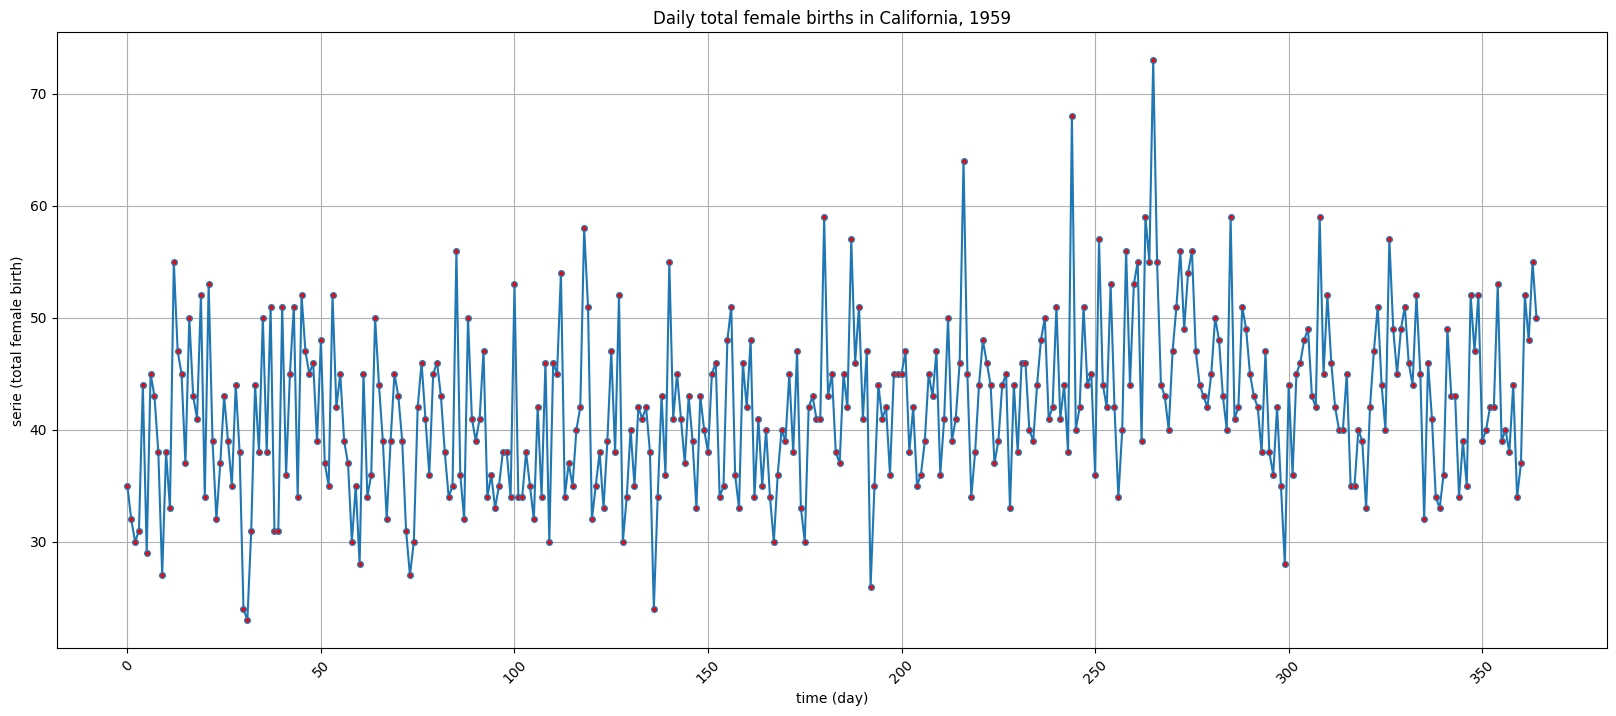

In [3]:

plt.figure(figsize=(20,8))
plt.plot(df.index, ts, markerfacecolor= "r", marker = "o", markersize = 4 )
plt.grid (True)
plt.title('Daily total female births in California, 1959')
plt.xlabel("time (day)")
plt.ylabel("serie (total female birth)")
plt.xticks(rotation = 45)
plt.show()


<div style="background-color: #e1f6fc; padding: 20px; border-radius: 10px; border: 1px solid #ddd; font-family: Arial, sans-serif; color: #333;">
  <h2 style="color: #2c3e50;">Step 1 — Basic Descriptive Statistics</h2>

  Before doing anything with stationarity, AR, MA, or ARMA, we need to understand the raw series. This step gives us a <span style="font-weight:bold;">numerical first look</span> at the time series:

  <div style="padding: 10px; border: 1px solid #ccc; border-radius: 5px; margin: 10px 0;">
    - The <b>mean</b> tells us the average number of daily births.<br>
    - The <b>standard deviation</b> and <b>variance</b> show how much the values fluctuate.<br>
    - The <b>min</b> and <b>max</b> help detect unusual spikes.
  </div>

  These values help us recognize whether the series might be stable or drifting over time.

  This step does <b>not</b> decide stationarity — it simply prepares our intuition for the next steps.
</div>

---

In [4]:
# ts = df['births']
print("TimeSerie statistics: ")
ts.describe()


TimeSerie statistics: 


count    365.000000
mean      41.980822
std        7.348257
min       23.000000
25%       37.000000
50%       42.000000
75%       46.000000
max       73.000000
Name: births, dtype: float64

<div style="background-color: #e1f6fc; padding: 20px; border-radius: 10px; border: 1px solid #ddd; font-family: Arial, sans-serif; color: #333;">
  <h2 style="color: #2c3e50;">Step 2 — Compare the First Half and Second Half of the Time Series</h2>

  Weak stationarity means that the <b>mean</b> and <b>variance</b> do not change much over time.

  To check this in a simple way:
  <div style="padding: 10px; border: 1px solid #ccc; border-radius: 5px; margin: 10px 0;">
    - We split the series into two equal halves.<br>
    - We compute the <b>mean</b> and <b>variance</b> of each half.
  </div>

  If the two halves have <b>similar mean and variance</b>, then the process is likely stable. If they differ significantly, it may indicate a trend or changing volatility.

  This step does <b>not</b> give a final decision — it simply guides us toward whether we might need to difference the data later.
</div>

---


In [5]:
mid = len(ts) // 2
first = ts.iloc[:mid]
second = ts.iloc[mid:]
mean_first = first.mean()
var_first = first.var()
mean_second = second.mean()
var_second = second.var()
mean_diff = mean_second - mean_first
var_diff = var_second - var_first
mean_diff_pct = (mean_diff / mean_first) * 100
var_diff_pct = (var_diff / var_first) * 100
print(f"total length: {len(ts)}, split index: {mid}, first half rows: {len(first)}, second half rows: {len(second)}")
print(f"mean_first: {mean_first:.4f}")
print(f"var_first: {var_first:.4f}")
print(f"mean_second: {mean_second:.4f}")
print(f"var_second: {var_second:.4f}")
print(f"absolute difference in means: {mean_diff:.4f}")
print(f"percent difference in means: {mean_diff_pct:.2f}%")
print(f"absolute difference in variances: {var_diff:.4f}")
print(f"percent difference in variances: {var_diff_pct:.2f}%")


total length: 365, split index: 182, first half rows: 182, second half rows: 183
mean_first: 39.7637
var_first: 49.4853
mean_second: 44.1858
var_second: 48.9763
absolute difference in means: 4.4221
percent difference in means: 11.12%
absolute difference in variances: -0.5090
percent difference in variances: -1.03%


<div style="background-color: #e1f6fc; padding: 20px; border-radius: 10px; border: 1px solid #ddd; font-family: Arial, sans-serif; color: #333;">
  <h2 style="color: #2c3e50;">Report 2 — Half-to-Half Stationarity Check (Summary)</h2>
  
  We compared the first and second halves of the series to see if mean and variance remain stable.
  
  <h3 style="color: #2980b9;">Results</h3>
  <div style="padding: 10px; border: 1px solid #ccc; border-radius: 5px; margin: 10px 0;">
    - <b>Mean:</b> 39.76 → 44.19 (<b>+11.1%</b>)<br>
    - <b>Variance:</b> 49.49 → 48.98 (<b>−1.0%</b>)
  </div>
  
  <h3 style="color: #2980b9;">Interpretation</h3>
  - The <b>mean increases noticeably</b> (about 11%). This hints at a mild upward drift → possible violation of weak stationarity.<br>
  - The <b>variance is stable</b>, suggesting no change in volatility.
  
  <h3 style="color: #2980b9;">Conclusion</h3>
  The series is <i>almost</i> stationary but may have a small trend in the mean. We need formal tests (ADF + KPSS) to confirm whether differencing is required.
</div>

---

<div style="background-color: #e1f6fc; padding: 20px; border-radius: 10px; border: 1px solid #ddd; font-family: 'Georgia', serif; color: #333;">
  <h2 style="color: #2c3e50; font-family: 'Arial', sans-serif;">Step 3 — Purpose of ADF and KPSS Tests</h2>

  Now that we inspected the mean and variance manually, we use formal statistical tests to check whether the series is weakly stationary.

  We use two standard tests:

  <h3 style="color: #2980b9; font-family: 'Arial', sans-serif;">ADF (Augmented Dickey–Fuller)</h3>
  <div style="padding: 10px; border: 1px solid #ccc; border-radius: 5px; margin: 10px 0;">
    <ul style="list-style-type: square; padding-left: 20px;">
      <li><b>Null hypothesis:</b> The series is non-stationary.</li>
      <li>If <code>p-value &lt; 0.05</code>, we reject the null → suggests <b>stationary</b>.</li>
    </ul>
  </div>

  <h3 style="color: #2980b9; font-family: 'Arial', sans-serif;">KPSS (Kwiatkowski–Phillips–Schmidt–Shin)</h3>
  <div style="padding: 10px; border: 1px solid #ccc; border-radius: 5px; margin: 10px 0;">
    <ul style="list-style-type: square; padding-left: 20px;">
      <li><b>Null hypothesis:</b> The series is stationary.</li>
      <li>If <code>p-value &lt; 0.05</code>, we reject the null → suggests <b>non-stationary</b>.</li>
    </ul>
  </div>

  Using both is the standard approach:
  <div style="padding: 10px; border: 1px solid #ccc; border-radius: 5px; margin: 10px 0;">
    <ul style="list-style-type: square; padding-left: 20px;">
      <li><b>ADF detects unit roots</b> (non-stationarity).</li>
      <li><b>KPSS detects level-stationarity.</b></li>
      <li><i>Agreement between them</i> leads to a clear conclusion.</li>
    </ul>
  </div>

  This step tells us whether differencing is required before fitting AR/MA/ARMA models.
</div>

---

In [6]:
adf_result = adfuller(ts)
print("ADF statistic:", adf_result[0])
print("ADF p-value:", adf_result[1])

kpss_result = kpss(ts, regression='c', nlags='auto')
print("KPSS statistic:", kpss_result[0])
print("KPSS p-value:", kpss_result[1])


ADF statistic: -4.808291253559763
ADF p-value: 5.243412990149865e-05
KPSS statistic: 1.6129657593856863
KPSS p-value: 0.01


<div style="background-color: #e1f6fc; padding: 20px; border-radius: 10px; border: 1px solid #ddd; font-family: 'Georgia', serif; color: #333;">
  <h1 style="color: #2c3e50; font-family: 'Arial', sans-serif;">Report 3 — Interpretation of ADF & KPSS</h1>

  <h3 style="color: #2980b9; font-family: 'Arial', sans-serif;">1. Results</h3>
  <div style="overflow-x:auto;">
    <table style="border-collapse: collapse; width: 100%; margin: 10px 0;">
      <thead>
        <tr>
          <th style="border: 1px solid #ddd; padding: 8px; text-align: left;">Test</th>
          <th style="border: 1px solid #ddd; padding: 8px; text-align: left;">Statistic</th>
          <th style="border: 1px solid #ddd; padding: 8px; text-align: left;">p-value</th>
          <th style="border: 1px solid #ddd; padding: 8px; text-align: left;">Interpretation</th>
        </tr>
      </thead>
      <tbody>
        <tr>
          <td style="border: 1px solid #ddd; padding: 8px;">ADF</td>
          <td style="border: 1px solid #ddd; padding: 8px; font-family: 'Arial', sans-serif; font-size: 16px;">-4.808</td>
          <td style="border: 1px solid #ddd; padding: 8px; font-family: 'Arial', sans-serif; font-size: 16px;">0.000052</td>
          <td style="border: 1px solid #ddd; padding: 8px;">Reject H₀ → <i>series appears stationary</i></td>
        </tr>
        <tr>
          <td style="border: 1px solid #ddd; padding: 8px;">KPSS</td>
          <td style="border: 1px solid #ddd; padding: 8px; font-family: 'Arial', sans-serif; font-size: 16px;">1.613</td>
          <td style="border: 1px solid #ddd; padding: 8px; font-family: 'Arial', sans-serif; font-size: 16px;">0.01</td>
          <td style="border: 1px solid #ddd; padding: 8px;">Reject H₀ → <i>series appears non-stationary</i></td>
        </tr>
      </tbody>
    </table>
  </div>

  <h3 style="color: #2980b9; font-family: 'Arial', sans-serif;">2. Why do they contradict?</h3>
  <p>
    ADF → stationary<br>
    KPSS → non-stationary
  </p>
  
  This usually means the series is:
  <ul style="list-style-type: disc; padding-left: 20px;">
    <li><i>Trend-stationary</i> (stationary after removing a deterministic trend)</li>
    <li>Affected by <i>structural breaks</i></li>
    <li>Exhibiting <i>seasonality</i></li>
    <li>Having <i>shifting mean levels</i> across the year</li>
  </ul>

  These patterns can pass one test and fail the other. A statistic is a number calculated from your time series that measures how strongly the data supports or contradicts the null hypothesis.

  <h3 style="color: #2980b9; font-family: 'Arial', sans-serif;">3. Practical Takeaway</h3>
  Because the tests disagree, the series is likely <i>not fully stationary</i>.

  Next steps usually are:
  <ul style="list-style-type: disc; padding-left: 20px;">
    <li>Inspect trend</li>
    <li>Inspect seasonality</li>
    <li>Apply differencing or seasonal differencing</li>
    <li>Re-run stationarity tests after differencing</li>
  </ul>
</div>


<div style="background-color: #e1f6fc; padding: 20px; border-radius: 10px; border: 1px solid #ddd; font-family: 'Georgia', serif; color: #333;">
  <h1 style="color: #2c3e50; font-family: 'Arial', sans-serif;">Step 4</h1>

  <h3 style="color: #2980b9; font-family: 'Arial', sans-serif;">What are we doing and why?</h3>
  
  The ADF and KPSS tests gave <b>conflicting results</b>, which is very common with real time-series. 

  To resolve this, the typical next step is:

  <ol style="padding-left: 20px;">
    <li><b>Visually inspect the differenced series:</b> Differencing removes trend or slow drifts.</li>
    <li><b>Check if the differenced series looks stationary:</b> A stationary series will look like random noise with no visible upward or downward drift.</li>
    <li><b>Re-run ADF and KPSS on the differenced series:</b> If both tests now agree (ADF: stationary, KPSS: stationary), then the original series is integrated of order 1 → <i>I(1)</i>.</li>
  </ol>

  This step helps us decide:

  <ul style="list-style-type: disc; padding-left: 20px;">
    <li>Whether ARMA is enough, or</li>
    <li>Whether we must use ARIMA with <i>d = 1</i>.</li>
  </ul>
</div>

---

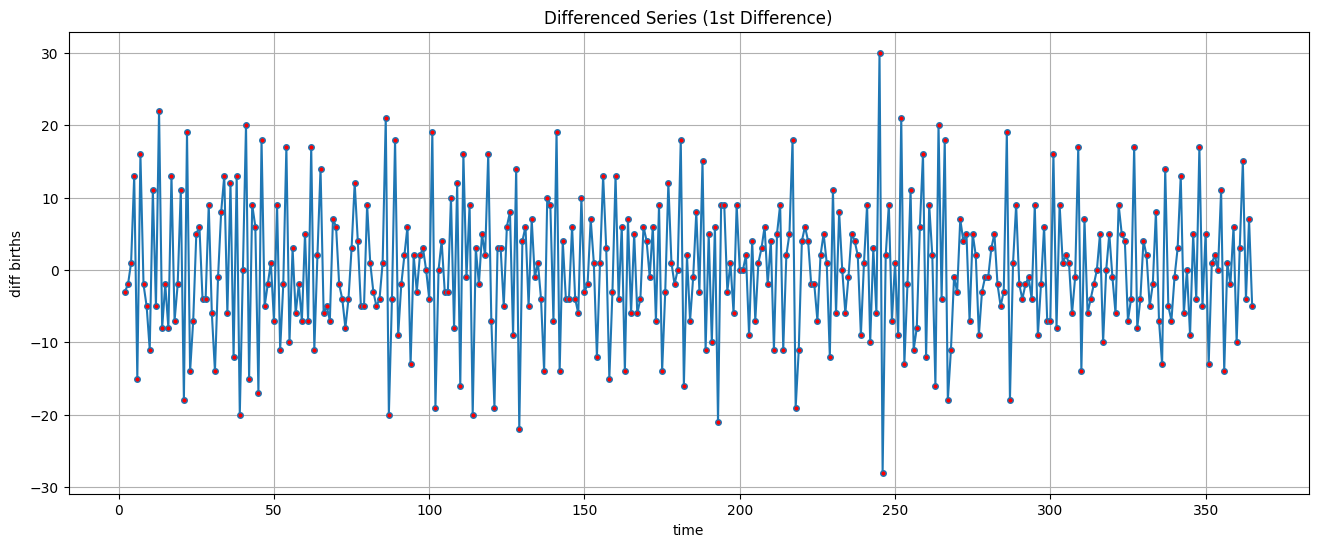

ADF statistic (diff): -12.625178633871343
ADF p-value (diff): 1.5472400091969784e-23

KPSS statistic (diff): 0.18738808325724707
KPSS p-value (diff): 0.1


In [14]:
ts_diff = ts.diff().dropna()

plt.figure(figsize=(16,6))
plt.plot(ts_diff.index, ts_diff, markerfacecolor= "r", marker = "o", markersize = 4 )
plt.grid(True)
plt.title("Differenced Series (1st Difference)")
plt.xlabel("time")
plt.ylabel("diff births")
plt.show()

adf_stat, adf_p, _, _, _, _ = adfuller(ts_diff)
kpss_stat, kpss_p, _, _ = kpss(ts_diff, regression='c')

print(f"ADF statistic (diff): {adf_stat}")
print(f"ADF p-value (diff): {adf_p}\n")
print(f"KPSS statistic (diff): {kpss_stat}")
print(f"KPSS p-value (diff): {kpss_p}")



<div style="background-color: #e1f6fc; padding: 20px; border-radius: 10px; border: 1px solid #ddd; font-family: 'Georgia', serif; color: #333;">
  <h2 style="color: #2c3e50; font-family: 'Arial', sans-serif;">Report 4 — Interpretation of Differenced Series</h2>

  <ul style="list-style-type: disc; padding-left: 20px;">
    <li>The plot of the differenced series shows values fluctuating around zero with roughly constant variance.</li>
    <li><b>ADF test:</b> statistic = <span style="font-family: 'Arial', sans-serif; font-size: 16px;">-12.625</span>, p-value ≈ <span style="font-family: 'Arial', sans-serif; font-size: 16px;">0</span> → strongly reject non-stationarity → series is stationary.</li>
    <li><b>KPSS test:</b> statistic = <span style="font-family: 'Arial', sans-serif; font-size: 16px;">0.187</span>, p-value = <span style="font-family: 'Arial', sans-serif; font-size: 16px;">0.1</span> → fail to reject stationarity → series is stationary.</li>
    <li>Both tests now agree that the differenced series is stationary.</li>
    <li>Conclusion: the original series is integrated of order 1 (<i>I(1)</i>), meaning it becomes stationary after one differencing.</li>
    <li>Next step: examine <b>ACF</b> and <b>PACF</b> to determine appropriate AR and MA orders for ARIMA modeling.</li>
  </ul>
</div>

---

<div style="background-color: #e1f6fc; padding: 20px; border-radius: 10px; border: 1px solid #ddd; font-family: 'Georgia', serif; color: #333;">
  <h2 style="color: #2c3e50; font-family: 'Arial', sans-serif;">Step 5 — Examine ACF and PACF</h2>

  We now analyze the autocorrelation and partial autocorrelation of the differenced series:

  <ul style="list-style-type: disc; padding-left: 20px;">
    <li><b>ACF (Autocorrelation Function):</b> shows correlation between current value and its past values (lags).</li>
    <li><b>PACF (Partial Autocorrelation Function):</b> shows correlation with past values after removing effects of intermediate lags.</li>
    <li>These plots help us decide the <b>p (AR order)</b> and <b>q (MA order)</b> for ARIMA(<i>p</i>,1,<i>q</i>) modeling.</li>
    <li>Only the differenced series (stationary) should be analyzed with ACF/PACF.</li>
  </ul>
</div>

---

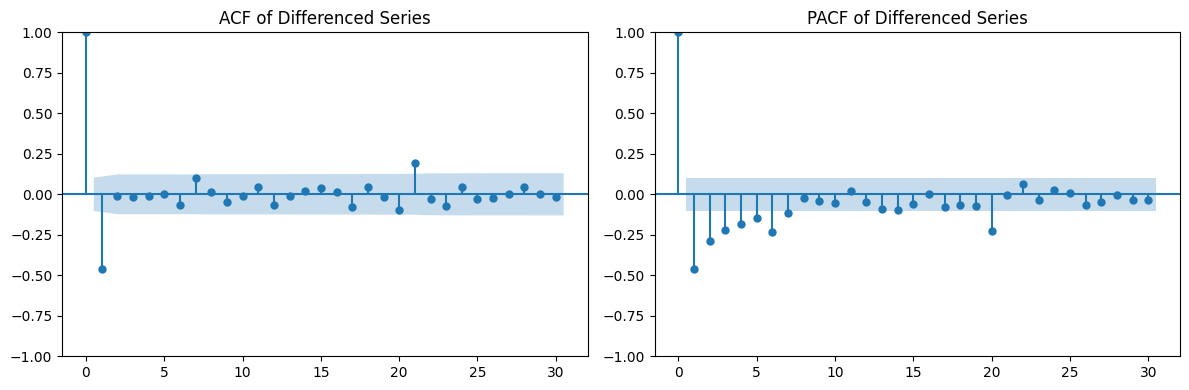

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

plot_acf(ts_diff, lags=30, ax=axes[0])
axes[0].set_title("ACF of Differenced Series")

plot_pacf(ts_diff, lags=30, method='ywm', ax=axes[1])
axes[1].set_title("PACF of Differenced Series")

plt.tight_layout()
plt.show()


<div style="background-color: #e1f6fc; padding: 20px; border-radius: 10px; border: 1px solid #ddd; font-family: 'Georgia', serif; color: #333;">
  <h2 style="color: #2c3e50; font-family: 'Arial', sans-serif;">Report 5 — Interpreting ACF & PACF of Differenced Series</h2>

  <h3 style="color: #2980b9; font-family: 'Arial', sans-serif;">ACF (top plot):</h3>
  <ul style="list-style-type: disc; padding-left: 20px;">
    <li>Only the first lag has a noticeable spike outside the confidence bounds.</li>
    <li>All other lags are within the shaded region → weak autocorrelation beyond lag 1.</li>
    <li>Suggests a <b>MA(1)</b> component might be sufficient.</li>
  </ul>


  <h3 style="color: #2980b9; font-family: 'Arial', sans-serif;">Overall takeaway:</h3>
  <ul style="list-style-type: disc; padding-left: 20px;">
    <li>Differenced series looks stationary (consistent with Step 4 tests).</li>
    <li>For MA(<i>q</i>), the plots suggest starting with <b>MA(1)</b> as a candidate model.</li>
    <li>These are starting points; later we can refine using AIC/BIC or cross-validation.</li>
  </ul>
</div>

---

<div style="background-color: #e1f6fc; padding: 20px; border-radius: 10px; border: 1px solid #ddd; font-family: 'Georgia', serif; color: #333;">
  <h2 style="color: #2c3e50; font-family: 'Arial', sans-serif;">Step 6 — Fit ARIMA Model & Forecast</h2>

  Now that the series is stationary and we have an idea of AR (<i>p</i>) and MA (<i>q</i>) orders from Step 5:

  <ul style="list-style-type: disc; padding-left: 20px;">
    <li>Fit an <b>MA(1,q)</b> model to the original series.</li>
    <li><i>p</i> from PACF, <i>d=1</i> because we differenced once, <i>q</i> from ACF.</li>
    <li>Check model diagnostics (residuals should look like white noise).</li>
  </ul>
</div>

---

                               SARIMAX Results                                
Dep. Variable:                 births   No. Observations:                  365
Model:                 ARIMA(0, 1, 1)   Log Likelihood               -1229.110
Date:                Wed, 04 Feb 2026   AIC                           2462.221
Time:                        18:51:01   BIC                           2470.015
Sample:                             0   HQIC                          2465.319
                                - 365                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9480      0.018    -52.898      0.000      -0.983      -0.913
sigma2        49.8582      3.310     15.063      0.000      43.371      56.346
Ljung-Box (L1) (Q):                   4.22   Jarque-

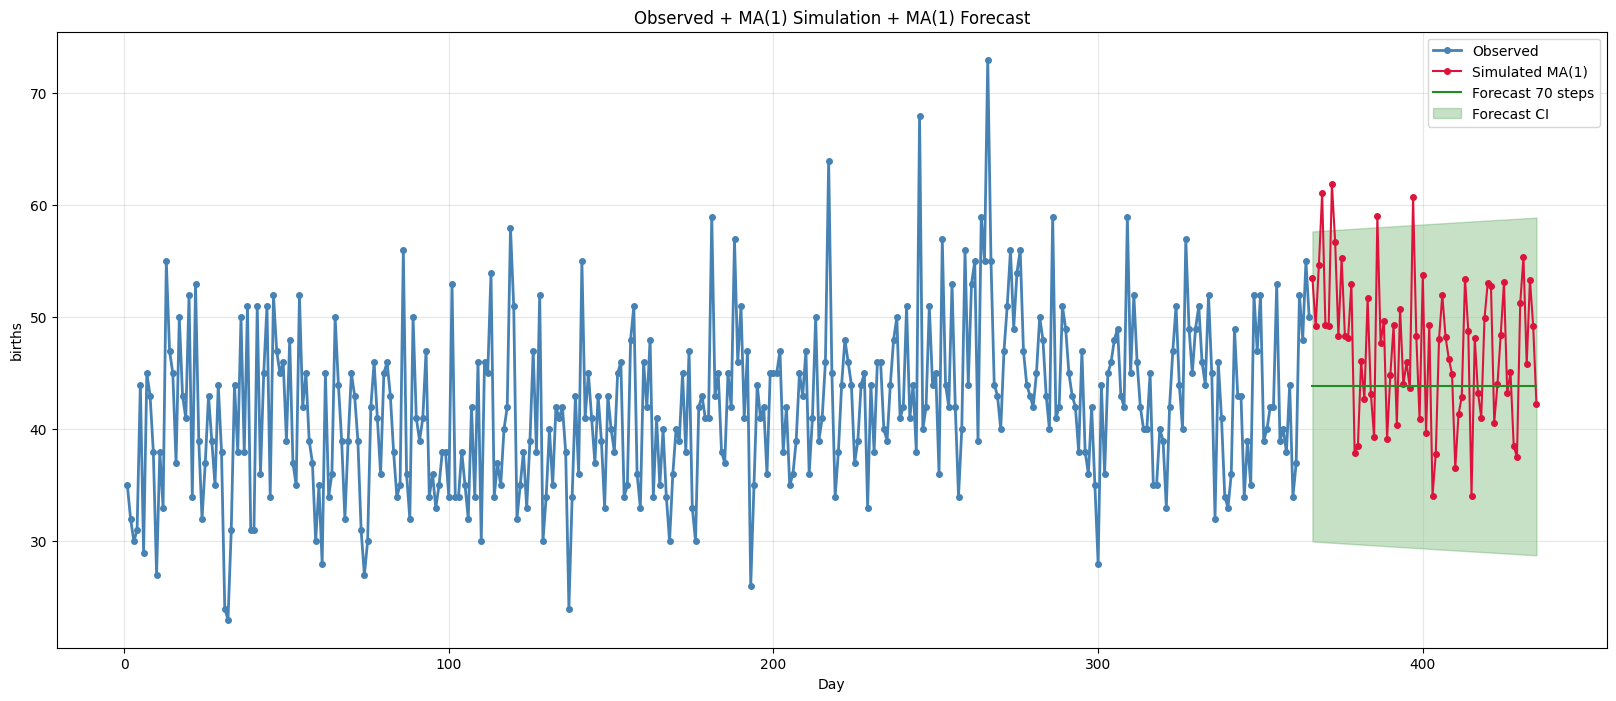

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import arma_generate_sample

p, d, q = 0, 1, 1

ts = df['births'].reset_index(drop=True).astype(float)
ts.index = ts.index + 1

model = ARIMA(ts, order=(p, d, q))
model_fit = model.fit()

ma = model_fit.params['ma.L1']
sigma2 = model_fit.params['sigma2']

ar_coefs = np.array([1])
ma_coefs = np.array([1, ma])

print(model_fit.summary())

steps = 70
np.random.seed(42)

sim_diffs = arma_generate_sample(ar=ar_coefs, ma=ma_coefs, nsample=steps, scale=np.sqrt(sigma2))

start_idx = ts.index.max() + 1
sim_index = range(start_idx, start_idx + steps)

if d == 1:
    last_value = ts.iloc[-1]
    sim_levels = last_value + np.cumsum(sim_diffs)
    sim_series = pd.Series(sim_levels, index=sim_index)
else:
    sim_series = pd.Series(sim_diffs, index=sim_index)

forecast = model_fit.get_forecast(steps=steps)
mean = forecast.predicted_mean
ci = forecast.conf_int()

plt.figure(figsize=(20, 8))
plt.plot(ts.index, ts.values, label='Observed', color='steelblue', linewidth=2, marker='o', markersize=4)
plt.plot(sim_series.index, sim_series.values, label='Simulated MA(1)', color='crimson', linewidth=1.5, marker='o', markersize=4)
plt.plot(mean.index, mean.values, label=f'Forecast {steps} steps', color='forestgreen')
plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color='forestgreen', alpha=0.25, label='Forecast CI')
plt.xlabel("Day")
plt.ylabel("births")
plt.title("Observed + MA(1) Simulation + MA(1) Forecast")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



<div style="background-color: #e1f6fc; padding: 20px; border-radius: 10px; border: 1px solid #ddd; font-family: 'Georgia', serif; color: #333;">

## Report 6 — Short Version (updated)

**Model fitted:** `ARIMA(0,1,1)` &nbsp;&nbsp; (an MA(1) on first differences)

* **MA(1) coefficient:** $\hat\theta_1 = -0.9480$ (std. err. = 0.018, $p < 0.001$)
* **Innovation variance:** $\hat\sigma^2 = 49.8582$ (std. err. = 3.310)
* **Sample size:** $N=365$
* **Log Likelihood:** $-1229.110$, **AIC:** $2462.221$, **BIC:** $2470.015$
* **Ljung–Box (L1):** $Q=4.22$, $\text{Prob}(Q)=0.04$ — indicates residual autocorrelation at lag 1
* **Jarque–Bera:** $\text{JB p}=0.00$ — residuals deviate from normality

</div>

<div style="background-color: #e1f6fc; padding: 20px; border-radius: 10px; border: 1px solid #ddd; font-family: 'Georgia', serif; color: #333; margin-top: 16px;">

## Final mathematical formulas (rendered)

Define the first difference $\Delta X_t = X_t - X_{t-1}$.

The fitted difference equation is:

$$\boxed{\Delta X_t = \varepsilon_t + \theta_1 \varepsilon_{t-1}, \quad \hat\theta_1 = -0.9480}$$

Equivalently, in levels:

$$\boxed{X_t = X_{t-1} + \varepsilon_t - 0.9480 \varepsilon_{t-1}}$$

The innovations are estimated as:

$$\varepsilon_t \sim \mathcal{N}(0, 49.8582), \quad \hat\sigma \approx 7.062$$

</div>